In [30]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

print("OpenCV:", cv2.__version__)

def show_segmentation_result(bgr: np.ndarray, mask: np.ndarray, n: int, color_labels: np.ndarray) -> None:
    overlay = cv2.addWeighted(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), 0.65, color_labels, 0.35, 0)
    plt.figure()
    plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    plt.figure()
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.show()
    plt.figure()
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()
    print(n)


OpenCV: 4.12.0


In [31]:
def morph_reconstruct(marker: np.ndarray, mask: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    
    marker = marker.astype(np.uint8).copy()
    mask = mask.astype(np.uint8)
    while True:
        dil = cv2.dilate(marker, kernel)
        nxt = cv2.bitwise_and(dil, mask)
        if np.array_equal(nxt, marker):
            return marker
        marker = nxt

def fill_holes_binary(binary_fg: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    
    inv = cv2.bitwise_not(binary_fg)
    marker = np.zeros_like(inv)
    marker[0, :] = inv[0, :]
    marker[-1, :] = inv[-1, :]
    marker[:, 0] = np.maximum(marker[:, 0], inv[:, 0])
    marker[:, -1] = np.maximum(marker[:, -1], inv[:, -1])
    r = morph_reconstruct(marker, inv, kernel)
    return cv2.bitwise_not(r)

def remove_border_touching(binary_fg: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    
    marker = np.zeros_like(binary_fg)
    marker[0, :] = binary_fg[0, :]
    marker[-1, :] = binary_fg[-1, :]
    marker[:, 0] = np.maximum(marker[:, 0], binary_fg[:, 0])
    marker[:, -1] = np.maximum(marker[:, -1], binary_fg[:, -1])
    r = morph_reconstruct(marker, binary_fg, kernel)
    return cv2.bitwise_and(binary_fg, cv2.bitwise_not(r))

def segment_and_count(
    gray: np.ndarray,
    *,
    invert_after_otsu: bool = False,
    open_kernel_size: int = 5,
    close_kernel_size: int = 7,
    min_area: int = 500,
    reconstruct_kernel_size: int = 3,
) -> tuple:
    
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if invert_after_otsu:
        bw = cv2.bitwise_not(bw)

    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_kernel_size, open_kernel_size))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel_size, close_kernel_size))
    k_rec = cv2.getStructuringElement(cv2.MORPH_RECT, (reconstruct_kernel_size, reconstruct_kernel_size))

    x = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k_open)
    x = cv2.morphologyEx(x, cv2.MORPH_CLOSE, k_close)
    x = fill_holes_binary(x, k_rec)
    x = remove_border_touching(x, k_rec)

    n, labels, stats, _ = cv2.connectedComponentsWithStats((x > 0).astype(np.uint8), connectivity=8)
    keep = np.zeros_like(x)
    rng = np.random.default_rng(42)
    color = np.zeros((*x.shape, 3), dtype=np.uint8)
    for i in range(1, n):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area >= min_area:
            m = labels == i
            keep[m] = 255
            color[m] = rng.integers(40, 255, size=3, dtype=np.uint8)
    count = sum(1 for i in range(1, n) if int(stats[i, cv2.CC_STAT_AREA]) >= min_area)
    return keep, count, color

Fruits

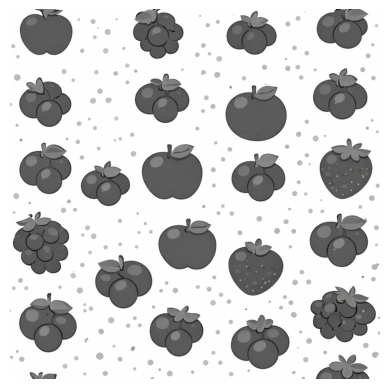

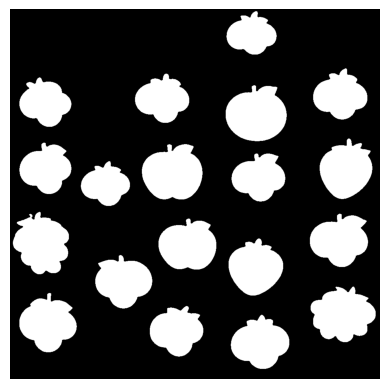

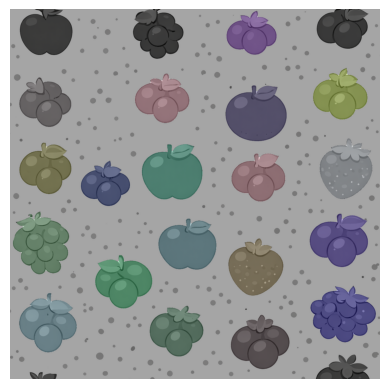

19


In [32]:
invert_after_otsu = True
open_kernel_size = 5
close_kernel_size = 5
min_area = 100

bgr = cv2.imread("COMP9517_26T1_Lab4_Images/Fruits.jpg")
if bgr is None:
    raise FileNotFoundError("COMP9517_26T1_Lab4_Images/Fruits.jpg")
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
mask, n, color_labels = segment_and_count(
    gray,
    invert_after_otsu=invert_after_otsu,
    open_kernel_size=open_kernel_size,
    close_kernel_size=close_kernel_size,
    min_area=min_area,
)
show_segmentation_result(bgr, mask, n, color_labels)


Strawberries

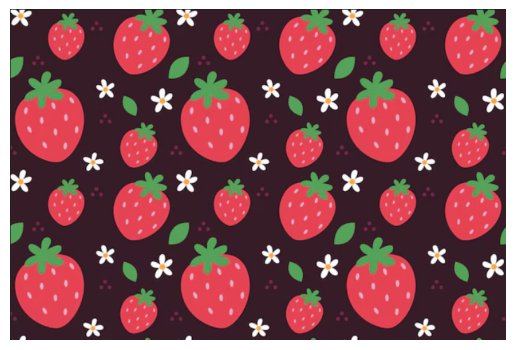

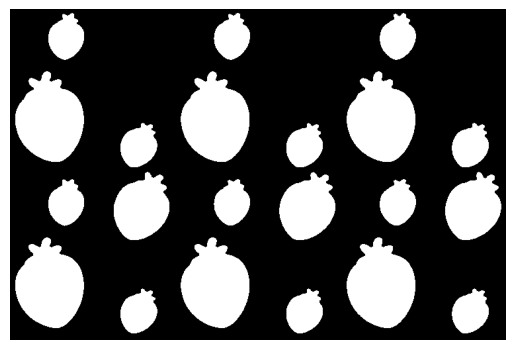

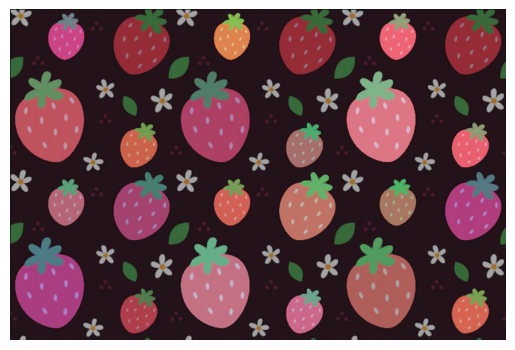

21


In [ ]:
# here is a change on min area, the flowers are too small. 
# If you use 100, there will be n = 51
invert_after_otsu = False
open_kernel_size = 5
close_kernel_size = 5
min_area = 1000

bgr = cv2.imread("COMP9517_26T1_Lab4_Images/Strawberries.jpg")
if bgr is None:
    raise FileNotFoundError("COMP9517_26T1_Lab4_Images/Strawberries.jpg")
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
mask, n, color_labels = segment_and_count(
    gray,
    invert_after_otsu=invert_after_otsu,
    open_kernel_size=open_kernel_size,
    close_kernel_size=close_kernel_size,
    min_area=min_area,
)
show_segmentation_result(bgr, mask, n, color_labels)


Monsters

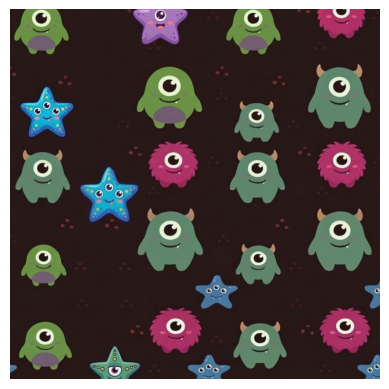

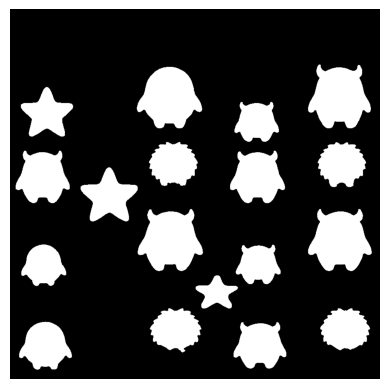

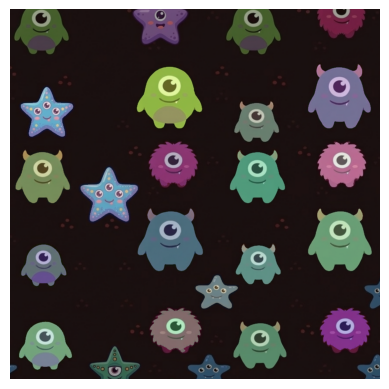

18


In [34]:
invert_after_otsu = False
open_kernel_size = 5
close_kernel_size = 5
min_area = 100

bgr = cv2.imread("COMP9517_26T1_Lab4_Images/Monsters.jpg")
if bgr is None:
    raise FileNotFoundError("COMP9517_26T1_Lab4_Images/Monsters.jpg")
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
mask, n, color_labels = segment_and_count(
    gray,
    invert_after_otsu=invert_after_otsu,
    open_kernel_size=open_kernel_size,
    close_kernel_size=close_kernel_size,
    min_area=min_area,
)
show_segmentation_result(bgr, mask, n, color_labels)
